# e7_ext_e5_dropout

This is the baseline experiment. It includes following components in the model:
* 64x64x3 input size
* Data Augmentations
* 8 Convolutional Layers
* Pooling Layer after skipping 1 convolutional Layer each
* SGD optimizer

### Importing required modules
Importing basic modules for training:
* torch
* datasets and transform
* dataloader

Importing Architecture:
* Architecture

Importing custom utils
* Trainer
* tester
* gen_line_charts

In [1]:
# torch and modules
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Main architecture
from Architecture import Architecture

# custom utils and modules
from modules.trainer import Trainer
from modules.tester import test
from modules.charts import gen_line_charts

## Load data
Use datasets, transforms and DataLoader to:
* LoadData
* Resize image to 64x64
* Randomly flip images horizontally
* Randomly rotate image by +-10 deg
* Add Color Jitters
* Randomly move the image
* transform to tensor
* Add a small Random Erasing between 2% to 10% erasing

For all three datasets: train, val and test

In [2]:
image_size = 64

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor()
])

# make train sets
train_datasets = datasets.ImageFolder("./datasets/train", transform)
train_loader = DataLoader(
    dataset=train_datasets, 
    batch_size=32,
    num_workers=4,
    pin_memory=True,
    shuffle=True,
    persistent_workers=True
)

# make validation sets
val_datasets = datasets.ImageFolder("./datasets/val", transform)
val_loader = DataLoader(
    dataset=val_datasets, 
    batch_size=32,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

# make test sets
test_datasets = datasets.ImageFolder("./datasets/test", transform)
test_loader = DataLoader(
    dataset=test_datasets, 
    batch_size=32,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

## Define and Use Architecture
define a model by calling Architecture class and add layers to it:
* 8 Convolutional Layer each followed with skipping pooling layer
* 1 Flatten Layer followed with a 128 fully connected neural network
* 1 Linear layer to generate 3 class logits

In [3]:
model = Architecture()

Using function to loop adding 8 convolutional layers with a skip pooling layer 

In [4]:
def add_conv_layers(layers=1, skip_pool=0):
    # define in and out channels
    in_channels = 3
    out_channels = 8
    # size
    size = image_size
    # skip pool increase by one for calculation
    skip_pool = skip_pool+1
    # save a trainable parameters
    total_conv_params = 0
    # loop each layers to add on model
    for layer in range(layers):
        # Convolutional Layer
        model.add(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )
        # calculate trainable params
        total_conv_params += (((3*3*in_channels) + 1) * out_channels) + (2*out_channels)
        # Pooling Layer
        if  (layer + 1) % skip_pool:
            model.add(nn.MaxPool2d(2,2))
            size = size//2
        # update in and out channels
        if (layer<layers-1):
            in_channels = out_channels
            out_channels = out_channels*2
    # return total convolutional layer parameters
    return total_conv_params, out_channels, size

Call the `add_conv_layers()` and store parameters

In [5]:
conv_params, out_channels, size = add_conv_layers(8, 1)

# print conv params and out_channels
print(f"Total Trainable Parameters: {conv_params}")
print(f"Final Features: {out_channels}")
print(f"Final Feature size: {size}x{size}")

Total Trainable Parameters: 6297408
Final Features: 1024
Final Feature size: 4x4


use `model.add()` to add:
* Flatten Layer (1024x4x4)
* Hidden Layer (1024x4x4->128)
* Output Layer (128->3)

In [6]:
# calculate input
n_in = out_channels*size*size
print(f"Input vector size = {n_in}")

model.add(
    # Flatten
    nn.Flatten(),
    # Hidden Layer
    nn.Linear(n_in, 128),
    nn.ReLU(),
    # Dropout
    nn.Dropout(0.3),
    # Output Layer
    nn.Linear(128, 3),
    nn.ReLU()
)

Input vector size = 16384


Calculating total parameters of the model

In [7]:
total_trainable_parameters = ((n_in*128)+128) + ((128*3)+3)
print(f"Total trainable parameters = {total_trainable_parameters}")

Total trainable parameters = 2097667


### Defining optimizer and Criterion
Optimizer:
* SGD
* learning rate = 2e-4
* no weight decay

Critetion:
* nn.CrossEntropy()

In [8]:
# optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=3e-4)
# criterion 
criterion = nn.CrossEntropyLoss()

## Train the model
Use Trainer Function to train the complete model for 100 epochs

In [9]:
trainer = Trainer(
    model,
    train_loader,
    val_loader,
    optimizer,
    "cuda",
    criterion
)

In [10]:
save_path = "./experiments/e7_ext_e5_dropout"

In [11]:
metrics = trainer.fit(100, save_path, 1)

EPOCH 5 completed | Training Loss = 0.9343044046145766 | Validation Loss = 0.9477165063222249
EPOCH 10 completed | Training Loss = 0.7649938135004756 | Validation Loss = 0.83637908299764
EPOCH 15 completed | Training Loss = 0.6639144554067014 | Validation Loss = 0.7678246855735779
EPOCH 20 completed | Training Loss = 0.5732779089194625 | Validation Loss = 0.7145793477694193
EPOCH 25 completed | Training Loss = 0.5165187929993245 | Validation Loss = 0.6716787874698639
EPOCH 30 completed | Training Loss = 0.44389181928848154 | Validation Loss = 0.631332681576411
EPOCH 35 completed | Training Loss = 0.3991469262696024 | Validation Loss = 0.6028804282347361
EPOCH 40 completed | Training Loss = 0.3578253779838334 | Validation Loss = 0.5848980526129405
EPOCH 45 completed | Training Loss = 0.31713403183132854 | Validation Loss = 0.5775603810946147
EPOCH 50 completed | Training Loss = 0.27989428256874654 | Validation Loss = 0.5714863727490107
EPOCH 55 completed | Training Loss = 0.254047994404

## Plot the training metrics
Plotting line chart of training metrics that shows curves of loss, accuracy, precision, recall and f1-score for training set and validation set. 

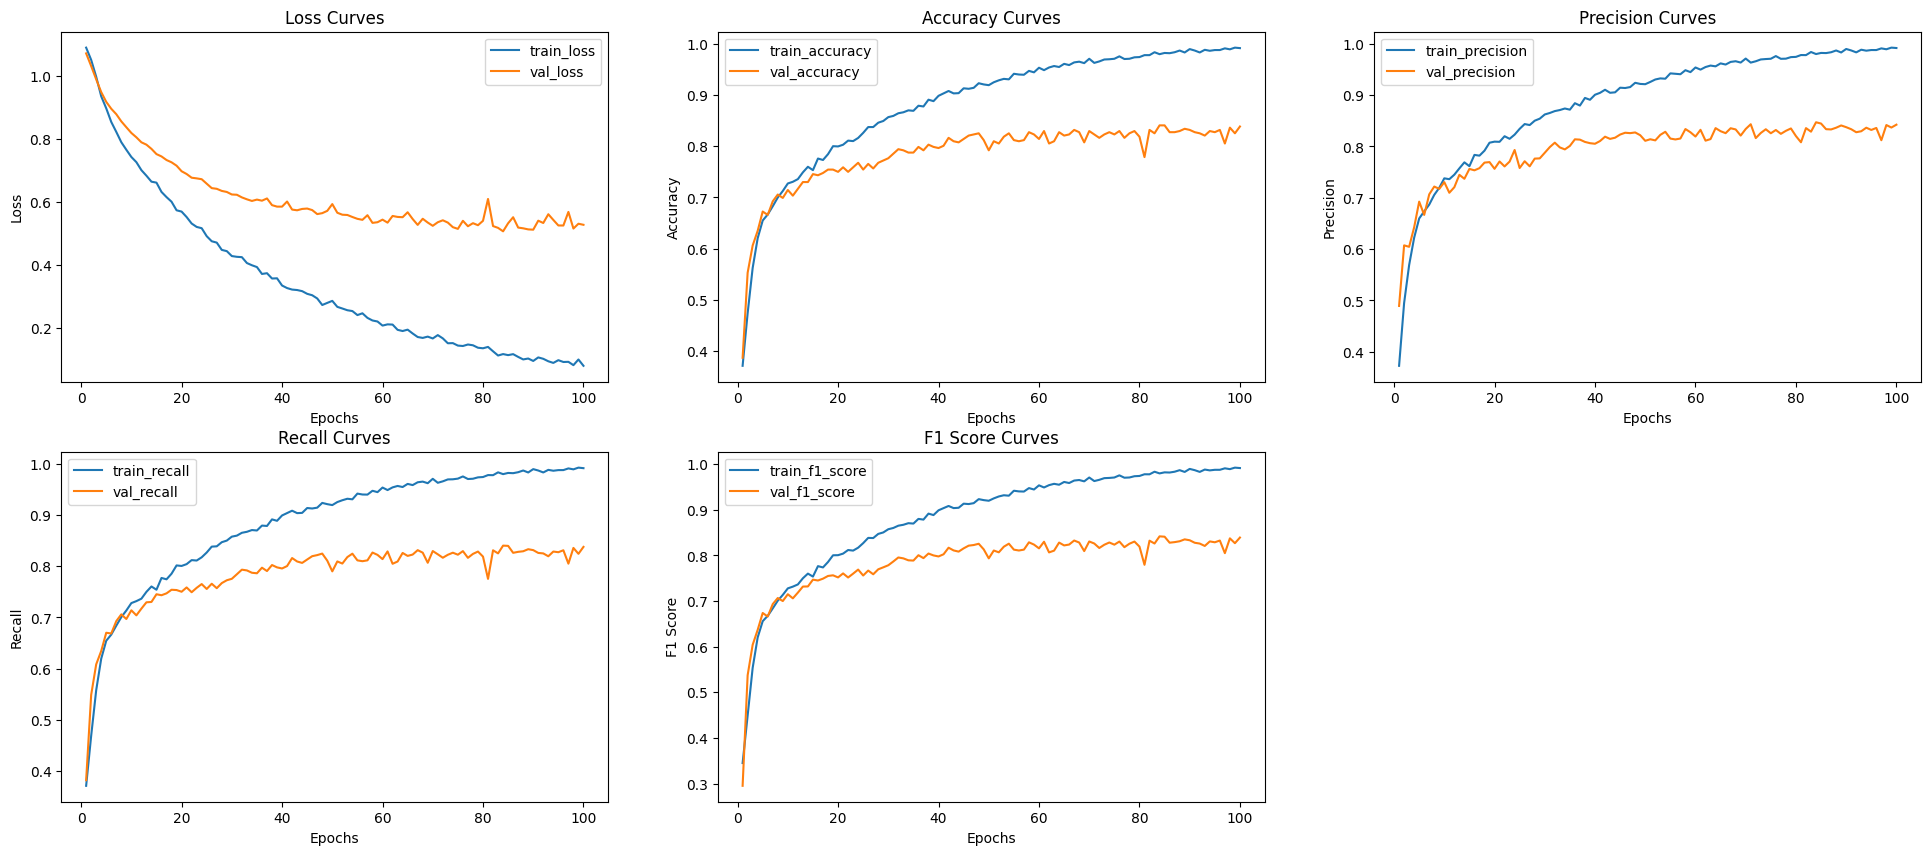

In [12]:
gen_line_charts(metrics, save_path, "training_metrics_graph.png", ["train_", "val_"])

### Model Evaluation
The loss curve on the training set tends to decrease smoothly approaching 0 indicating the model is learning on the traininig set. The loss curve on the validation set tends to decrease and stabalize at approximately 0.6. The curves have no extreme peaks and valleys and maintains a very smooth flow in comparison similar to experiment 5. A clear gap between training loss and validation loss is visible indicating possible overfittings.

The accuracy, precision, recall and F1-score curve shows a similar pattern throughout the epochs. The training curve rises approximating towards 1.00. The validation curve also tends to rise approximating around 0.84. Both training and validation curves are smoothly rising without extreme fluctuations. The curves indicates the model was learning smoothly while generalizing well throughout the training. The curves shows slightly lower gap between training and validation lines than experiment 5 suggesting slight improvement on overfitting. The best performing model is at epoch 83 with all metrics approximately 0.84 while the training metrics were approximately around 0.97 showing imporovement over experiment 5 with increased 0.03 (~3%) on the validation set.

Overall the model is showed a slow but stable learning. Though the validation scores comparatively less than in previous experiments, this experiments shows better learning and generalizing. Overfitting is present but the model generalizes well with the validation set. 

## Testing the epoch 83 for making a good evaluation

In [13]:
tested = test(model, "./experiments/e7_ext_e5_dropout/models/epoch_84.pt", test_loader, criterion, "cuda")

In [14]:
tested

{'test_accuracy': 0.8618421052631579,
 'test_precision': 0.865082742316785,
 'test_recall': 0.8622003557895758,
 'test_f1_score': 0.8622385636519914,
 'test_loss': 0.37579801119863987}

## Test Evaluation
The 84th epoch shows a promising result giving 83% of accuracy, precision, recall and f1_score. The test loss is approximately 0.45. The model can be used for making the predictions.  The test results are slightly higher than the test result of experiment 5.